# RetailPulse

# Customer Segmentation using Machine Learning

---

## Objective

This notebook performs customer segmentation using **K-Means Clustering** based on customer purchasing behaviour.

The objective is to:

- Load the feature engineered dataset.
- Explore customer behaviour.
- Standardize numerical features.
- Identify the optimal number of clusters.
- Train a K-Means clustering model.
- Assign business-friendly customer segments.
- Visualize customer groups.
- Export outputs for Streamlit and Power BI dashboards.

---

## Dataset

Input:

`../data/customer_features.csv`

Outputs:

- `../outputs/rfm_segments.csv`
- `../outputs/cluster_summary.csv`

---

Author: Gulafsha

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
rfm = pd.read_csv("../data/customer_features.csv")

print("Dataset Loaded Successfully ✅")

print("\nShape:", rfm.shape)

rfm.head()

Dataset Loaded Successfully ✅

Shape: (4312, 9)


,Customer_ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000


In [3]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

rfm.info()

print("\n")

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(rfm.isnull().sum())

print("\n")

print("=" * 60)
print("Statistical Summary")
print("=" * 60)

display(rfm.describe().round(2))

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          4312 non-null   float64
 1   Recency              4312 non-null   int64  
 2   Frequency            4312 non-null   int64  
 3   Monetary             4312 non-null   float64
 4   Total_Quantity       4312 non-null   int64  
 5   Total_Revenue        4312 non-null   float64
 6   Invoice_Count        4312 non-null   int64  
 7   Unique_Products      4312 non-null   int64  
 8   Average_Order_Value  4312 non-null   float64
dtypes: float64(4), int64(5)
memory usage: 303.3 KB


Missing Values
Customer_ID            0
Recency                0
Frequency              0
Monetary               0
Total_Quantity         0
Total_Revenue          0
Invoice_Count          0
Unique_Products        0
Average_Order_Value    0
dtype: int64


Statistical Summary


,Customer_ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
count,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00
mean,15349.29,91.17,4.46,2040.41,1280.05,2040.41,4.46,63.65,376.37
std,1701.20,96.86,8.17,8911.76,6457.93,8911.76,8.17,85.76,492.36
min,12346.00,1.00,1.00,2.95,1.00,2.95,1.00,1.00,2.95
25%,13882.50,18.00,1.00,307.19,156.00,307.19,1.00,17.00,179.49
50%,15350.50,53.00,2.00,701.62,380.00,701.62,2.00,38.00,285.05
75%,16834.25,136.00,5.00,1714.93,992.00,1714.93,5.00,79.25,421.48
max,18287.00,374.00,205.00,349164.35,220600.00,349164.35,205.00,1741.00,11880.84


In [4]:
# ==========================================
# Feature Selection
# ==========================================

features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Total_Revenue",
    "Invoice_Count",
    "Unique_Products",
    "Average_Order_Value"
]

X = rfm[features]

print("Selected Features:")
print(features)

print("\nShape of Feature Matrix:", X.shape)

X.head()

Selected Features:
['Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Total_Revenue', 'Invoice_Count', 'Unique_Products', 'Average_Order_Value']

Shape of Feature Matrix: (4312, 8)


,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,165,11,372.86,70,372.86,11,26,33.896364
1,3,2,1323.32,828,1323.32,2,70,661.660000
2,74,1,222.16,373,222.16,1,20,222.160000
3,43,3,2671.14,993,2671.14,3,90,890.380000
4,11,1,300.93,261,300.93,1,21,300.930000


In [5]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Standardized Successfully ✅")

print("Scaled Data Shape:", X_scaled.shape)

Data Standardized Successfully ✅
Scaled Data Shape: (4312, 8)


In [6]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

scaled_df.head()

,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
0,0.762299,0.801087,-0.187139,-0.187396,-0.187139,0.801087,-0.439032,-0.695667
1,-0.910402,-0.300603,-0.080475,-0.070007,-0.080475,-0.300603,0.074100,0.579497
2,-0.177305,-0.423013,-0.204052,-0.140472,-0.204052,-0.423013,-0.509004,-0.313251
3,-0.497389,-0.178193,0.070784,-0.044454,0.070784,-0.178193,0.307341,1.044092
4,-0.827799,-0.423013,-0.195212,-0.157817,-0.195212,-0.423013,-0.497342,-0.153247


## Elbow Method

The Elbow Method helps determine the optimal number of customer clusters.

The K-Means model is trained using different values of **K**, and the Within-Cluster Sum of Squares (WCSS) is calculated.

The point where the curve starts flattening indicates the optimal number of clusters.

In [7]:
# ==========================================
# Elbow Method
# ==========================================

wcss = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

print("WCSS Calculated Successfully ✅")

WCSS Calculated Successfully ✅


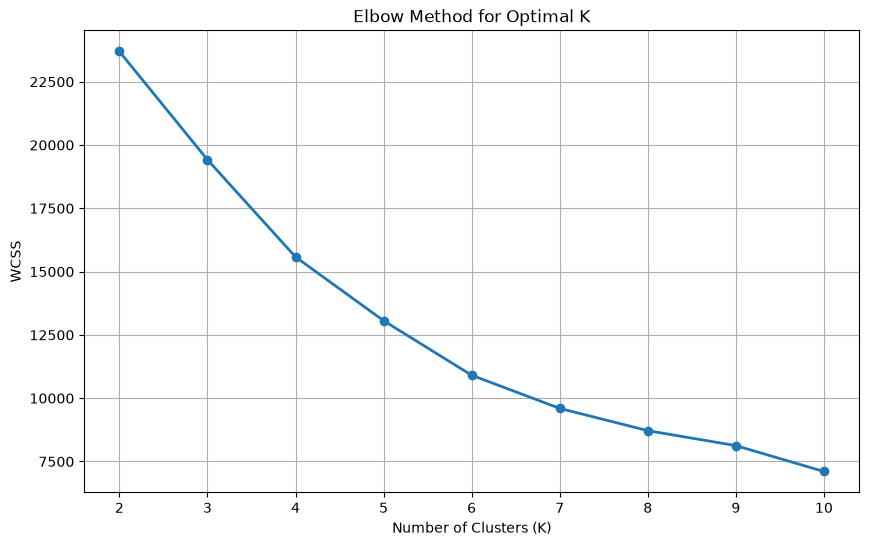

In [8]:
# ==========================================
# Elbow Curve
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Optimal K")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# Train the K-Means Clustering Model

Based on the Elbow Method, the optimal number of clusters is selected as **5**.

The K-Means algorithm groups customers with similar purchasing behaviour into five distinct customer segments.

In [9]:
# ==========================================
# Train K-Means Model
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print("✅ K-Means Model Trained Successfully!")

rfm.head()

✅ K-Means Model Trained Successfully!


,Customer_ID,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value,Cluster
0,12346.0,165,11,372.86,70,372.86,11,26,33.896364,4
1,12347.0,3,2,1323.32,828,1323.32,2,70,661.660000,1
2,12348.0,74,1,222.16,373,222.16,1,20,222.160000,1
3,12349.0,43,3,2671.14,993,2671.14,3,90,890.380000,1
4,12351.0,11,1,300.93,261,300.93,1,21,300.930000,1


# Cluster Distribution

This section displays the number of customers assigned to each cluster.

In [10]:
# ==========================================
# Cluster Distribution
# ==========================================

cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

cluster_counts

Cluster
0     651
1    2615
2       5
3      37
4    1004
Name: count, dtype: int64


Cluster
0     651
1    2615
2       5
3      37
4    1004
Name: count, dtype: int64

# Cluster Profiling

The average values of each feature are calculated for every cluster to understand customer behaviour.

In [11]:
# ==========================================
# Cluster Summary
# ==========================================

cluster_summary = (
    rfm.groupby("Cluster")[features]
       .mean()
       .round(2)
)

cluster_summary

,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
Cluster,,,,,,,,
0,26.83,11.27,5214.40,2940.91,5214.40,11.27,177.42,545.37
1,48.50,3.01,973.09,574.16,973.09,3.01,45.22,334.64
2,5.60,113.60,215535.00,119640.20,215535.00,113.60,875.20,2235.02
3,39.03,49.89,35203.53,33460.76,35203.53,49.89,300.32,2183.65
4,246.37,1.59,476.91,266.29,476.91,1.59,25.10,299.64


In [12]:
# ==========================================
# Save Cluster Summary
# ==========================================

cluster_summary.to_csv(
    "../outputs/cluster_summary.csv"
)

print("✅ cluster_summary.csv saved successfully!")

✅ cluster_summary.csv saved successfully!


# Business Interpretation

The following table summarizes the average customer behaviour for each cluster. This helps identify high-value, loyal, regular, and at-risk customer groups.

In [13]:
# ==========================================
# Business Interpretation
# ==========================================

print("=" * 60)
print("BUSINESS INTERPRETATION")
print("=" * 60)

display(cluster_summary)

BUSINESS INTERPRETATION


,Recency,Frequency,Monetary,Total_Quantity,Total_Revenue,Invoice_Count,Unique_Products,Average_Order_Value
Cluster,,,,,,,,
0,26.83,11.27,5214.40,2940.91,5214.40,11.27,177.42,545.37
1,48.50,3.01,973.09,574.16,973.09,3.01,45.22,334.64
2,5.60,113.60,215535.00,119640.20,215535.00,113.60,875.20,2235.02
3,39.03,49.89,35203.53,33460.76,35203.53,49.89,300.32,2183.65
4,246.37,1.59,476.91,266.29,476.91,1.59,25.10,299.64


# Customer Segment Labels

The numeric cluster IDs are converted into meaningful business segments based on the customer behaviour observed in the cluster profiling results.

In [14]:
# ==========================================
# Assign Business Labels
# ==========================================

segment_map = {
    0: "Lost Customers",
    1: "VIP Customers",
    2: "High Value Customers",
    3: "Regular Customers",
    4: "Loyal Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(segment_map)

print("✅ Customer segments assigned successfully!")

rfm[["Customer_ID", "Cluster", "Customer_Segment"]].head()

✅ Customer segments assigned successfully!


,Customer_ID,Cluster,Customer_Segment
0,12346.0,4,Loyal Customers
1,12347.0,1,VIP Customers
2,12348.0,1,VIP Customers
3,12349.0,1,VIP Customers
4,12351.0,1,VIP Customers


# Customer Segment Distribution

The chart below shows the number of customers in each business segment.

C:\Users\hp\AppData\Local\Temp\ipykernel_18920\502609969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


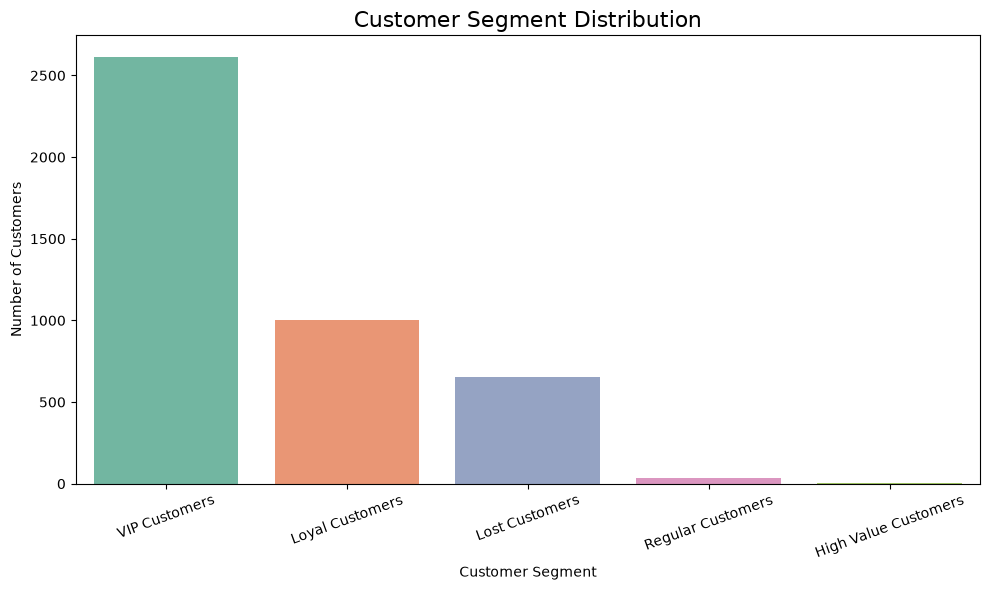

In [15]:
# ==========================================
# Customer Segment Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x="Customer_Segment",
    order=rfm["Customer_Segment"].value_counts().index,
    palette="Set2"
)

plt.title("Customer Segment Distribution", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Customer Behaviour Analysis

This scatter plot visualizes customer clusters based on Monetary Value and Purchase Frequency.

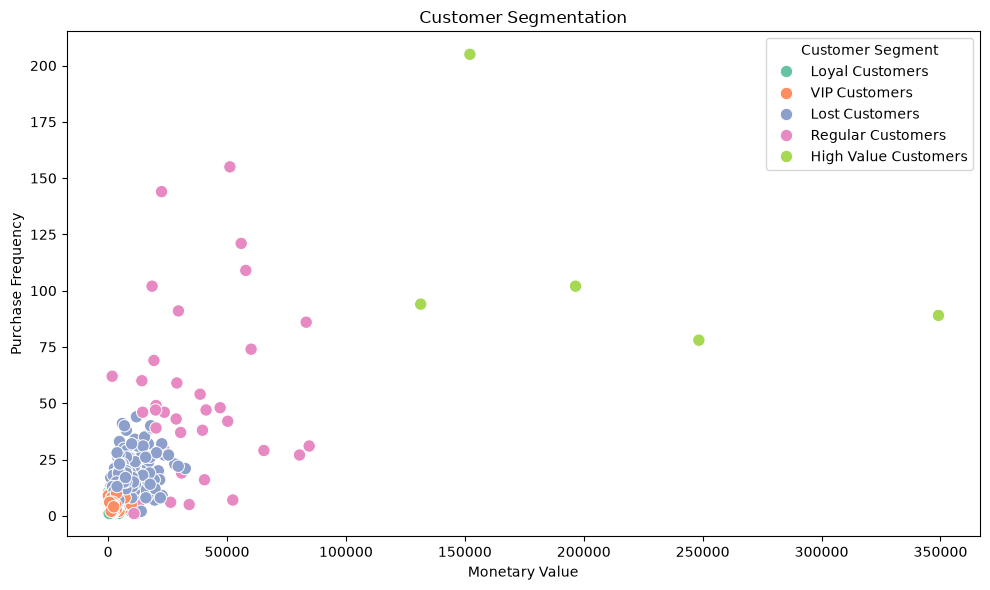

In [16]:
# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Monetary",
    y="Frequency",
    hue="Customer_Segment",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation")
plt.xlabel("Monetary Value")
plt.ylabel("Purchase Frequency")

plt.legend(title="Customer Segment")

plt.tight_layout()

plt.show()

# Revenue Distribution by Customer Segment

The box plot compares the revenue generated by each customer segment.

C:\Users\hp\AppData\Local\Temp\ipykernel_18920\217606444.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


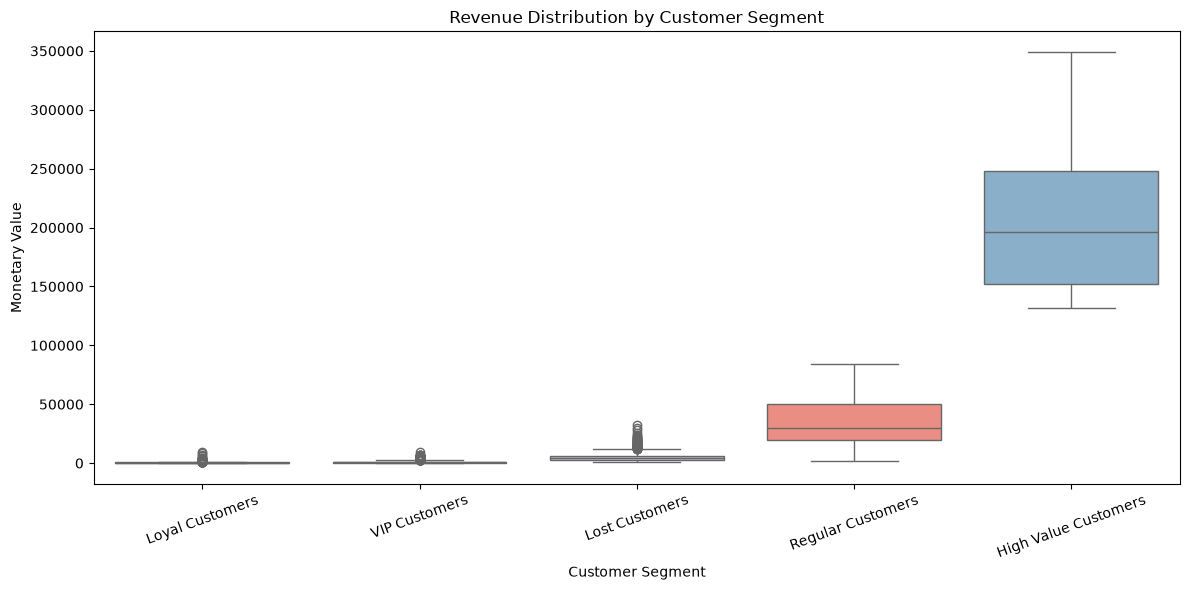

In [17]:
# ==========================================
# Revenue Distribution
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=rfm,
    x="Customer_Segment",
    y="Monetary",
    palette="Set3"
)

plt.title("Revenue Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Monetary Value")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Save Outputs

The segmented customer dataset and cluster summary are exported for use in Streamlit and Power BI dashboards.

In [18]:
# ==========================================
# Save Outputs
# ==========================================

rfm.to_csv(
    "../outputs/rfm_segments.csv",
    index=False
)

cluster_summary.to_csv(
    "../outputs/cluster_summary.csv"
)

print("✅ rfm_segments.csv saved successfully!")
print("✅ cluster_summary.csv saved successfully!")

✅ rfm_segments.csv saved successfully!
✅ cluster_summary.csv saved successfully!


# Business Insights

Key observations derived from the customer segmentation model.

In [19]:
# ==========================================
# Business Insights
# ==========================================

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

largest_segment = rfm["Customer_Segment"].value_counts().idxmax()
largest_count = rfm["Customer_Segment"].value_counts().max()

highest_revenue = (
    rfm.groupby("Customer_Segment")["Monetary"]
       .mean()
       .idxmax()
)

highest_frequency = (
    rfm.groupby("Customer_Segment")["Frequency"]
       .mean()
       .idxmax()
)

print(f"📌 Largest Customer Segment : {largest_segment} ({largest_count} customers)")
print(f"💰 Highest Spending Segment : {highest_revenue}")
print(f"🛒 Most Frequent Buyers     : {highest_frequency}")
print("\nSegmentation completed successfully and ready for dashboards.")

BUSINESS INSIGHTS
📌 Largest Customer Segment : VIP Customers (2615 customers)
💰 Highest Spending Segment : High Value Customers
🛒 Most Frequent Buyers     : High Value Customers

Segmentation completed successfully and ready for dashboards.


In [21]:
import pickle
import os

# Create models folder ONE LEVEL UP
os.makedirs("../models", exist_ok=True)

# Save KMeans model
with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save Scaler
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Saved in RetailPulse/models/")

✅ Saved in RetailPulse/models/


# Conclusion

This notebook successfully segmented customers using the K-Means Clustering algorithm.

### Achievements

- Loaded the feature engineered customer dataset.
- Standardized customer behavioural features.
- Determined the optimal number of clusters using the Elbow Method.
- Trained a K-Means clustering model.
- Assigned meaningful business labels.
- Generated customer behaviour visualizations.
- Exported segmentation outputs for Streamlit and Power BI.

The generated files will be used in the Customer Analytics Dashboard and Customer Behaviour Dashboard.

In [1]:
import pandas as pd

df = pd.read_csv(r"D:\RetailPulse\data\customer_segments.csv")
print(df.columns.tolist())
print(df.head())

['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Total_Revenue', 'Invoice_Count', 'Unique_Products', 'Average_Order_Value', 'Cluster', 'Customer_Segment']
   Customer ID  Recency  Frequency  Monetary  Total_Quantity  Total_Revenue  \
0      12346.0      165         11    372.86              70         372.86   
1      12347.0        3          2   1323.32             828        1323.32   
2      12348.0       74          1    222.16             373         222.16   
3      12349.0       43          3   2671.14             993        2671.14   
4      12351.0       11          1    300.93             261         300.93   

   Invoice_Count  Unique_Products  Average_Order_Value  Cluster  \
0             11               26            33.896364        0   
1              2               70           661.660000        3   
2              1               20           222.160000        3   
3              3               90           890.380000        3   
4            